<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%205.1%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 데이터 전처리(Data Processing)



*   데이터 전처리는 ML 알고리즘만큼 중요하다. ML 알고리즘은 데이터에 기반하고 있기 때문에 어떤 데이터를 입력으로 가지느냐에 따라 결과도 크케 달라질 수 있다. 사이킷런의 ML 알고리즘을 적용하기 전에 데이터에 대해 미리 처리해야 할 기본 사항이 있다. 결손값, 즉 NaN, Null 값은 허용되지 않는다. 따라서 이러한 Null 값은 고정된 다른 값으로 변환해야 한다. Null 값을 어떻게 처리해야 할지는 경우에 따라 다른데, 피처 값 중 Null 값이 얼마 되지 않는다면 피처의 평균값 등으로 간단히 대체할 수 있다. 하지만 Null 값이 대부분이라면 오히려 해당 피처는 드랍하는 것이 더 좋다, 가장 결정이 힘든 부분이 Null 값이 일정 수준 이상 되는 경우로, 정확히 몇 퍼센트까지를 일정 수준 이상이라고 한다는 기준은 없지만 해당 피처가 중요도가 높은 피처이고 Null을 단순히 피처의 평균값으로 대체할 경우 예측 왜곡이 심할 수 있다면 더 정밀한 대체값을 선정해야 할 것이다.
*   사이킷런의 머신러닝 알고리즘은 문자열 값을 입력값으로 허용하지 않아, 모든 문자열 값은 인코딩돼서 숫자형으로 변환해야 한다. 문자열 피처는 일반적으로 카테고리형 피처와 텍스트형 피처를 의미한다. 카테고리형 피처는 코드 값으로 표현하는 게 더 이해하기 쉬울 것이며, 텍스트형 피처는 피처 벡터화 등의 기법으로 벡터화하거나 불필요한 피처(e.g. 주민번호, 단순 문자열 아이디)라고 판단되면 삭제하는 게 좋다. 이러한 식별자 피처는 단순히 데이터 로우를 식별하는 용도로 사용되기 때문에 예측에 중요한 요소가 될 수 없으며 오히려 알고리즘을 복잡하게 만들고 예측 성능을 떨어뜨리기 때문이다.

### 데이터 인코딩 - 레이블 인코딩과 원-핫 인코딩


*   **레이블 인코딩(Label encoding)**은 카테고리 피처를 코드형 숫자 값으로 변환하는 것이다. 예를 들어 상품 데이터의 상품 구분이 TV, 냉장고, 전자레인지, 컴퓨터, 선풍기, 믹서 값으로 돼 있다면, TV: 1, 냉장고: 2, 전자레인지: 3, 컴퓨터: 4, 선풍기: 5, 믹서: 6과 같은 숫자형 값으로 변환하는 것이다. 이 때 주의해야 할 점은 '01' '02' 와 같은 코드 값 역시 문자열이므로 1, 2와 같은 숫자형 값으로 변환되어야 한다는 것이다.
*   레이블 인코딩은 LabelEncoder 클래스로 구현한다. LabelEncoder를 객체로 생성한 후, fit()과 transform()을 호출해 레이블 인코딩을 수행한다.





In [1]:
from sklearn.preprocessing import LabelEncoder

items = ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

encoder = LabelEncoder()  ## LabelEncoder을 객체로 생성한다
encoder.fit(items)  ## fit() 호출
labels = encoder.transform(items)  ## transform() 호출
print('인코딩 변환값:', labels)

인코딩 변환값: [0 1 4 5 3 3 2 2]




*   데이터가 많은 경우에는 문자열 값이 어떤 숫자값으로 인코딩됐는지 직관적으로 알 수 없기에 **LabelEncoder 객체의 classes_ 속성값**으로 이를 확인할 수 있다.
*   classes_ 속성은 0번부터 순서대로 변환된 인코딩 값에 대한 원본값을 가지고 있어, TV가 0, 냉장고 1, 믹서 2, 선풍기 3, .. 로 인코딩됐음을 알 수 있다. **inverse_transform()**을 통해 인코딩된 값을 다시 디코딩할 수 있다.



In [3]:
print('인코딩 클래스:', encoder.classes_)  ## classes_ 속성값을 활용한다

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [4]:
print('디코딩 원본값:', encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']




*   레이블 인코딩은 간단하게 문자열 값을 숫자형 카테고리 값으로 변환해주는 매우 편리한 기능이지만, 레이블 인코딩을 통해 일괄적인 숫자 값으로 변환되면서 몇몇 ML 알고리즘에 이를 적용할 경우 예측 성능이 떨어지는 경우가 발생하기도 한다. 이는 숫자 값의 경우 크고 작음에 대한 특성이 작용하기 때문이다. 즉, 냉장고가 1, 믹서가 2로 변환되면 1보다 2가 더 큰 값이므로 특정 ML 알고리즘에서 가중치가 더 부여되거나 더 중요하게 인식될 가능성이 발생한다. 하지만 냉장고와 믹서의 숫자 변환 값은 단순 코드일 뿐이지 숫자 값에 따른 순서나 중요도로 인식돼서는 안 된다. 이러한 특성 때문에 레이블 인코딩은 선형회귀와 같은 ML 알고리즘에는 적용되지 않아야 한다. 트리 계열 ML 알고리즘은 숫자의 이러한 특성을 반영하지 않으므로 레이블 인코딩에 별 문제가 없다.
*   **원-핫 인코딩**은 피처 값의 유형에 따라 새로운 피처를 추가해 고유 값에 해당하는 칼럼에만 1을 표시하고 나머지 칼럼에는 0을 표시하는 방식이다. 즉, 행 형태로 돼 있는 피처의 고유 값을 열 형태로 차원을 변환한 뒤, 고유 값에 해당하는 칼럼에만 1을 표시하고 나머지 칼럼에는 0을 표시한다. (* 원-핫 = 여러 개의 속성 중 단 한 개의 속성만 1로 표시)


In [6]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

items = ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

items = np.array(items).reshape(-1, 1)  ## items를 22차원 ndarray로 변환한다

oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

print('원-핫 인코딩 데이터')   ## OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환한다
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


8개의 레코드와 1개의 칼럼을 가진 원본 데이터가 8개의 레코드와 6개의 칼럼을 가진 데이터로 변환되었다.



*   판다스에는 원-핫 인코딩을 더 쉽게 지원하는 API인 **get_dummies()**가 있다. 이를 통해 사이킷런의 OneHotEncoder와 다르게 문자열 카테고리 값을 숫자형으로 변환할 필요 없이 바로 변환할 수 있다.



In [7]:
import pandas as pd

df = pd.DataFrame({'item': ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


### 피처 스케일링과 정규화



*   **피처 스케일링(Feature Scaling)**은 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 말하며, 대표적인 방법으로 표준화와 정규화가 있다.
*   **표준화(Standardization)**은 데이터의 피처 각각이 평균이 0이고 분산이 1인 가우시안 정규 분포를 가진 값으로 변환하는 것을 의미한다. 표준화를 통해 변환될 피처 x의 새로운 i번째 데이터를 xi_new라고 한다면, 이 값은 원래 값에서 피처 x의 평균을 뺀 값을 피처 x의 표준편차로 나눈 값으로 계산할 수 있다.
*   **정규화(Normalization)**은 서로 다른 피처의 크기를 통일하기 위해 크기를 변환해주는 개념이다. 즉, 개별 데이터의 크기를 모두 똑같은 단위로 변경하는 것이다. 새로운 데이터 xi_new는 원래 값에서 피처 x의 최솟값을 뺀 값을 피처 x의 최댓값과 최솟값의 차이로 나눈 값으로 변환할 수 있다.
*   그런데 사이킷런의 전처리에서 제공하는 Normalizer 모듈과 일반적인 정규화는 약간의 차이가 있다. 사이킷런의 Normalizer 모듈은 선형대수에서의 정규화 개념이 적용됐으며, 개별 벡터의 크기를 맞추기 위해 변환하는 것을 의미한다. 즉, 개별 벡터를 모든 피처 벡터의 크기로 나눠준다. 세 개의 피처 x, y, z가 있다고 하면 새로운 데이터 xi_new는 원래 값에서 세 개의 피처의 i번째 피처 값에 해당하는 크기를 합한 값으로 나눠준다. = 앞으로 벡터 정규화로 지칭.





### StandardScaler



*   StandardScaler는 앞에서 설명한 표준화를 쉽게 지원하기 위한 클래스로, 개별 피처를 평균이 0이고 분산이 1인 값으로 변환해준다. 이렇게 가우시안 정규 분포를 가질 수 있도록 데이터를 변환하는 것은 몇몇 알고리즘에서 매우 중요한데, 특히 사이킷런에서 구현한 RBF 커널을 이용하는 서포트 벡터 머신(Support Vector Machine)이나 선형 회귀(Linear Regression), 로지스틱 회귀(Logistic Regression)는 데이터가 가우시안 분포를 가지고 있다고 가정하고 구현됐기 때문에 사전에 표준화를 적용하는 것은 예측 성능 향상에 중요한 요소가 될 수 있다.



In [9]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()   ## 붓꽃 데이터 세트를 로딩하고 DataFrame으로 변경한다
iris_data = iris.data
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)

print('feature들의 평균 값')
print(iris_df.mean())
print('\n feature들의 분산 값')
print(iris_df.var())

feature들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

 feature들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()   ## StandardScaler 객체를 생성한다
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)    ## fit()과 transform() 메서드에 변환 대상 피처 데이터 세트를 입력한다

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)   ## transform() 시 스케일이 변환된 데이터 세트가 NumPy ndarray로 반환되어 이를 DataFrame으로 변환한다
print('feature들의 평균 값')
print(iris_df_scaled.mean())
print('feature들의 분산 값')
print(iris_df_scaled.var())

feature들의 평균 값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64
feature들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


모든 칼럼 값의 평균이 0에 아주 가까운 값으로, 그리고 분산은 1에 아주 가까운 값으로 변환됐음을 알 수 있다.

### MinMaxScaler


*   MinMaxScaler는 데이터값을 0과 1 사이의 범위 값으로 변환한다. (* 음수 값이 있으면 -1에서 1 사이 범위 값으로 변환한다) 데이터의 분포가 가우시안 분포가 아닐 경우에 Min, Max Scale을 적용해볼 수 있다.





In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()   ## MinMaxScaler 객체를 생성한다
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)    ## fit()과 transform()을 호출해 MinMaxScaler로 데이터 세트를 변환한다

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)   ## transform() 시 스케일이 변환된 데이터 세트가 NumPy ndarray로 반환되어 이를 DataFrame으로 변환한다
print('feature들의 최솟값')
print(iris_df_scaled.min())
print('\n feature들의 최댓값')
print(iris_df_scaled.max())

feature들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

 feature들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


모든 피처에 0에서 1 사이의 값으로 변환되는 스케일링이 적용됐음을 알 수 있다.


### 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점


*   StandardScaler나 MinMaxScaler와 같은 Scaler 객체를 이용해 데이터의 스케일링을 변환할 때는 fit(), transform(), fit_transform() 메서드를 사용한다. 일반적으로 **fit()**은 데이터 변환을 위한 기준 정보 설정(e.g. 데이터 세트의 최댓값/최솟값 설정 등)을 적용하며 **transform()**은 이렇게 설정된 정보를 이용해 데이터를 변환한다. 그리고 **fit_transform()**은 fit()과 transform()을 한 번에 적용하는 기능을 수행한다.
*   그런데 학습 데이터 세트와 테스트 데이터 세트에 이 fit()과 transform을 적용할 때 주의가 필요하다. 바로 Scaler 객체를 이용해 학습 데이터로 fit()과 transform()을 적용하면 테스트 데이터 세트로는 다시 fit()을 수행하지 않고 학습 데이터 세트로 fit()을 수행한 결과를 이용해 transform() 변환을 적용해야 한다는 것이다. 즉, 학습 데이터로 fit()이 적용된 스케일링 기준 정보를 그대로 테스트 데이터에 적용해야 하며, 그렇지 않고 테스트 데이터로 다시 새로운 스케일링 기준을 만들게 되면 학습 데이터와 테스트 데이터의 스케일링 기준 정보가 서로 달라져 올바른 예측 결과를 도출하지 못할 수 있다.



In [13]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

## 학습 데이터는 0부터 10까지, 테스트 데이터는 0부터 5까지 값을 가지는 데이터 세트로 생성한다
## Scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1, 1)로 차원을 변경한다
train_array = np.arange(0, 11).reshape(-1, 1)
test_array = np.arange(0, 6).reshape(-1, 1)

In [14]:
scaler = MinMaxScaler()   ## MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0에서 1 사이의 값으로 변환된다

## 학습 데이터인 train_array부터 MinMaxScaler를 이용해 변환한다
scaler.fit(train_array)    ## fit()을 통해 train_array 데이터의 최솟값이 0, 최댓값이 10으로 설정된다
train_scaled = scaler.transform(train_array)    ## transform() 하게 되면 1/10 scale로 train_array 데이터가 변환되며, 원본 데이터 10은 1로 변환된다

print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [15]:
## 테스트 데이터도 변환한다
scaler.fit(test_array)   ## fit()을 통해 test_array 데이터의 최솟값이 0, 최댓값이 5로 설정된다
test_scaled = scaler.transform(test_array)    ## transform() 하게 되면 1/5 scale로 test_array 데이터가 변환되며, 원본 데이터 5는 1로 변환된다

print('원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


출력 결과를 확인하면 학습 데이터와 테스트 데이터의 스케일링이 맞지 않음을 알 수 있다. 이렇게 되면 학습 데이터와 테스트 데이터의 서로 다른 원본값이 동일한 값으로 변환되는 결과를 초래한다.


*   머신러닝 모델은 학습 데이터를 기반으로 학습되기에 반드시 테스트 데이터는 학습 데이터의 스케일링 기준에 따라야 하며, 테스트 데이터의 1 값은 학습 데이터와 동일하게 0.1 값으로 변환되어야 한다. 따라서 테스트 데이터에 다시 fit()을 적용해서는 안 되며, 학습 데이터로 이미 fit()이 적용된 Scaler 객체를 이용해 transform()으로 변환해야 한다.

In [16]:
scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

test_scaled = scaler.transform(test_array)  ## test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 한다
print('원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]




*   fit_transform()을 적용할 때에도 마찬가지이다. fit_transform()은 fit()과 transform()을 순차적으로 수행하는 메서드이므로 학습 데이터에서는 상관없지만 테스트 데이터에서는 절대 사용해서는 안 된다.
*   이렇게 학습과 테스트 데이터에 fit()과 transform()을 적용할 때 주의사항이 발생하므로 학습과 테스트 데이터 세트로 분리하기 전에 먼저 전체 데이터 세트에 스케일링을 적용한 뒤 학습과 데이터 세트로 분리하는 것이 더 바람직하다.

## 사이킷런으로 수행하는 타이타닉 생존자 예측





In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

titanic_df = pd.read_csv('/content/titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [2]:
print('\n ### 학습 데이터 정보 ### \n')
print(titanic_df.info())     ## DataFrame의 info() 메서드를 통해 로딩된 데이터 칼럼 타입을 확인한다


 ### 학습 데이터 정보 ### 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None




*   RangeIndex는 DataFrame 인덱스의 범위를 나타내므로 전체 로우 수를 알 수 있다. (e.g. RangeIndex가 891entries이므로 891개의 로우로 구성된다.) 판다스의 object 타입은 string 타입으로 봐도 무방하다. 판다스는 넘파이 기반으로 만들어졌고 넘파이의 String 타입이 길이 제한이 있어서 이에 대한 구분을 위해 object 타입으로 명기한 것이다.
*   사이킷런 머신러닝 알고리즘은 Null 값을 허용하지 않으므로 Null 값을 어떻게 처리할지 결정해야 한다. 여기서는 DataFrame의 fillna() 함수를 사용해 간단하게 Null 값을 평균 또는 고정 값으로 변경한다.



In [13]:
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
## Age 칼럼은 714개의 Not Null 값을 가지고 있으므로 177개의 Null값(NaN)을 가지고 있다.
## Age 칼럼의 Null 값을 평균 나이로 변경한다
titanic_df['Cabin'].fillna('N', inplace=True)
## Cabin 칼럼은 204개의 Not Null 값을 가지고 있으므로 608개의 Null값(NaN)을 가지고 있다
## Cabin 칼럼의 Null 값을 'N' 값으로 변경한다
titanic_df['Embarked'].fillna('N', inplace=True)
## Embarked 칼럼은 889개의 Not Null 값을 가지고 있으므로 2개의 Null값(NaN)을 가지고 있다
## Embarked 칼럼의 Null 값을 'N' 값으로 변경한다
print('데이터 세트 Null 값 개수 ', titanic_df.isnull().sum().sum())

데이터 세트 Null 값 개수  0


/tmp/ipykernel_937/1798826703.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
/tmp/ipykernel_937/1798826703.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [5]:
print(' Sex 값 분포: \n',titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포: \n', titanic_df['Embarked'].value_counts())

 Sex 값 분포: 
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

 Embarked 값 분포: 
 Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [6]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]   ## Cabin 속성값을 정리하기 전에 먼저 데이터를 탐색한다
print(titanic_df['Cabin'].head(3))

0    NaN
1      C
2    NaN
Name: Cabin, dtype: object


In [8]:
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()   ## 성별에 따른 생존자 수를 비교한다

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

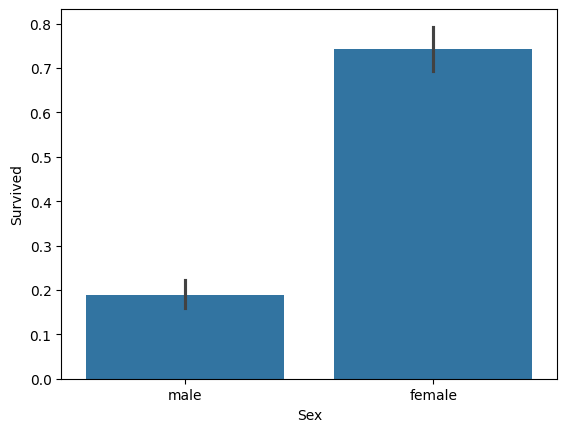

In [9]:
sns.barplot(x='Sex', y='Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

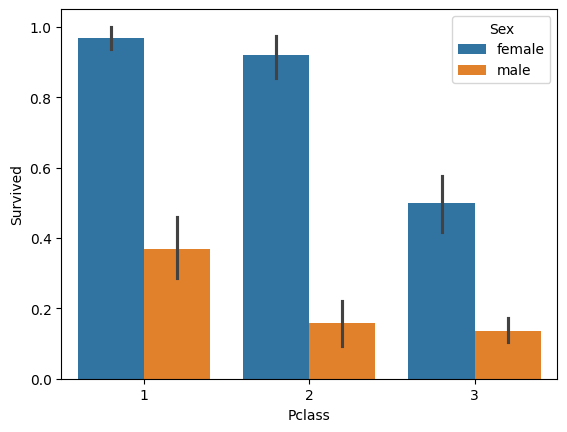

In [10]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)   ## 객실 등급별 성별에 따른 생존 확률을 시각화

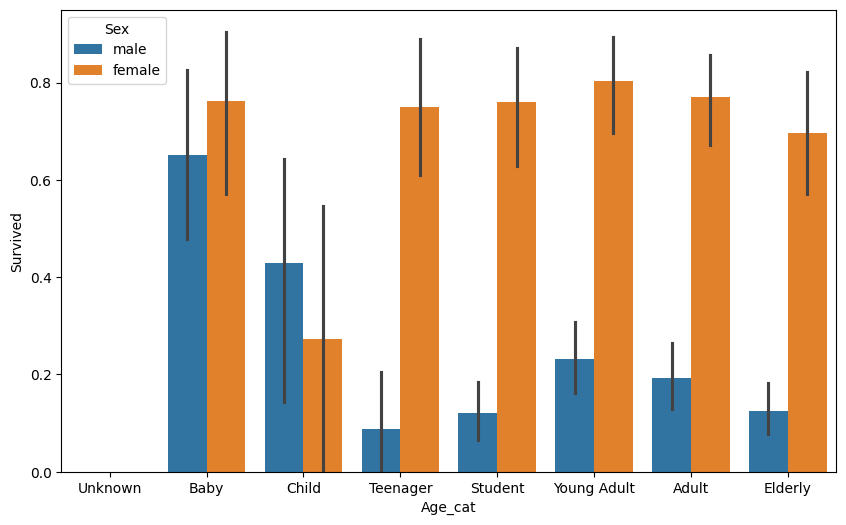

In [11]:
## 입력 age에 따라 구분 값을 반환하는 함수를 설정한다. DataFrame의 apply lambda 식에 사용한다
def get_category(age):
  cat = ''
  if age <= -1: cat = 'Unknown'
  elif age <= 5: cat = 'Baby'
  elif age <= 12: cat = 'Child'
  elif age <= 18: cat = 'Teenager'
  elif age <= 25: cat = 'Student'
  elif age <= 35: cat = 'Young Adult'
  elif age <= 60: cat = 'Adult'
  else : cat = 'Elderly'

  return cat

plt.figure(figsize=(10, 6))   ## 막대그래프 크기 figure를 더 크게 설정한다
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']  ## X축의 값을 순차적으로 표시하기 위한 설정이다

## lambda 식에 위에서 생성한 get_category() 함수를 반환값으로 지정한다
## get_category(X)는 입력값으로 'Age' 칼럼 값을 받아서 해당하는 cat을 반환한다
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)



*  LabelEncoder 객체는 카테고리 값의 유형 수에 따라 0 ~ (카테고리 유형 수-1)까지의 숫자 값으로 변환한다.



In [15]:
from sklearn.preprocessing import LabelEncoder  ## 남아있는 문자열 카테고리 피처를 숫자형 카테고리 피처로 변환하기 위해 레이블 인코딩을 적용한다

def encode_features(dataDF):
  features = ['Cabin', 'Sex', 'Embarked']   ## 여러 칼럼을 encode_features() 함수를 새로 생성해 한 번에 변환한다
  for feature in features:
    le = LabelEncoder()
    le = le.fit(dataDF[feature])
    dataDF[feature] = le.transform(dataDF[feature])

  return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3




*   데이터의 전처리를 전체적으로 호출하는 함수는 transform_features()이며 Null 처리, 불필요한 피처 제거, 인코딩을 수행하는 내부 함수로 구성된다. 불필요한 피처 제거는 drop_features(df)로 수행한다.




In [19]:
## Null 처리 함수
def fillna(df):
  df['Age'].fillna(df['Age'].mean(), inplace=True)
  df['Cabin'].fillna('N', inplace=True)
  df['Embarked'].fillna('N', inplace=True)
  df['Fare'].fillna(0, inplace=True)
  return df

## 머신러닝 알고리즘에 불필요한 피처를 제거한다
def drop_features(df):
  df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
  return df

## 레이블 인코딩을 수행한다
def format_features(df):
  df['Cabin'] = df['Cabin'].str[:1]
  features = ['Cabin', 'Sex', 'Embarked']
  for feature in features:
    le = LabelEncoder()
    le = le.fit(df[feature])
    df[feature] = le.transform(df[feature])
  return df

## 앞에서 설정한 데이터 전처리 함수를 호출한다
def transform_features(df):
  df = fillna(df)
  df = drop_features(df)
  df = format_features(df)
  return df

In [20]:
## 원본 데이터를 재로딩하고 피처 데이터 세트와 레이블 데이터 세트를 추출한다
titanic_df = pd.read_csv('/content/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

/tmp/ipykernel_937/3149561400.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_937/3149561400.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df,
                                                    test_size=0.2, random_state=11)   ## 별도의 테스트 데이터를 추출한다

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 결정트리, RandomForest, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스를 생성한다
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

## DecisionTreeClassifier 학습/예측/평가
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

## RandomForestClassifier 학습/예측/평가
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도: {0: .4f}'.format(accuracy_score(y_test, rf_pred)))

## LogisticRegression 학습/예측/평가
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:  0.8547
LogisticRegression 정확도: 0.8659


In [24]:
### 교차검증을 위해 결정 트리 모델을 조금 더 평가한다

from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
  ## 폴드 세트를 5개인 KFold 객체를 생성
  kfold = KFold(n_splits=folds)
  scores = []

  ## KFold 교차 검증 수행
  for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
    ## X_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성
    X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
    y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
    ## Classifier 학습, 예측, 정확도 계산
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    scores.append(accuracy)
    print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

  ## 5개 fold에서의 평균 정확도 계산
  mean_score = np.mean(scores)
  print("평균 정확도: {0:.4f}".format(mean_score))

## exec_kfold 호출
exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


In [25]:
## 교차검증을 cross_val_score() API를 이용해 수행한다

from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)
for iter_count, accuracy in enumerate(scores):
  print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

print("평균 정확도: {0:.4f}".format(np.mean(scores)))

교차 검증 0 정확도: 0.7430
교차 검증 1 정확도: 0.7753
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7865
교차 검증 4 정확도: 0.8427
평균 정확도: 0.7879


cross_val_Score()와 방금 전 K 폴드의 평균 정확도가 약간 다른데, 이는 cross_val_score()가 StratifiedKFolld를 이용해 폴드 세트를 분할하기 때문이다.

In [26]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth': [2, 3, 5, 10],
              'min_samples_split': [2, 3, 5], 'min_samples_leaf': [1, 5, 8]}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)
grid_dclf.fit(X_train, y_train)

print('GridSearchCV 최적 하이퍼 파라미터:', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

## GridSearchCV의 최적 하이퍼 파라미터로 학습된 Estimator로 예측 및 평가를 수행한다
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도: 0.8715
